<>:603: SyntaxWarning: invalid escape sequence '\e'
<>:603: SyntaxWarning: invalid escape sequence '\e'
C:\Users\bryan\AppData\Local\Temp\ipykernel_39320\2342291542.py:603: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta_{TPV}$ (%)')


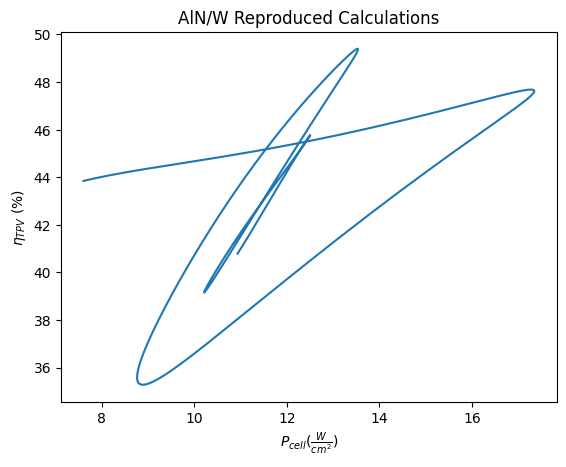

In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin

import numpy as np

import sys

import time

    #This is all the relevant TMM Code written by Steven Byrnes 

EPSILON = sys.float_info.epsilon # typical floating-point calculation error

def make_2x2_array(a, b, c, d, dtype=float):
    """
    Makes a 2x2 numpy array of [[a,b],[c,d]]

    Same as "numpy.array([[a,b],[c,d]], dtype=float)", but ten times faster
    """
    my_array = np.empty((2,2), dtype=dtype)
    my_array[0,0] = a
    my_array[0,1] = b
    my_array[1,0] = c
    my_array[1,1] = d
    return my_array

def is_forward_angle(n, theta):
    """
    if a wave is traveling at angle theta from normal in a medium with index n,
    calculate whether or not this is the forward-traveling wave (i.e., the one
    going from front to back of the stack, like the incoming or outgoing waves,
    but unlike the reflected wave).
    
    For real n & theta, the criterion is simply
    -pi/2 < theta < pi/2, but for complex n & theta, it's more complicated.
    See https://arxiv.org/abs/1603.02720 appendix D.
    
    If theta is the forward angle, then (pi-theta) is the backward angle and vice-versa.
    """
    assert n.real * n.imag >= 0, ("For materials with gain, it's ambiguous which "
                                  "beam is incoming vs outgoing. See "
                                  "https://arxiv.org/abs/1603.02720 Appendix C.\n"
                                  "n: " + str(n) + "   angle: " + str(theta))
    ncostheta = n * cos(theta)
    if abs(ncostheta.imag) > 100 * EPSILON:
        # Either evanescent decay or lossy medium. Either way, the one that
        # decays is the forward-moving wave
        answer = (ncostheta.imag > 0)
    else:
        # Forward is the one with positive Poynting vector
        # Poynting vector is Re[n cos(theta)] for s-polarization or
        # Re[n cos(theta*)] for p-polarization, but it turns out they're consistent
        # so I'll just assume s then check both below
        answer = (ncostheta.real > 0)
    # convert from numpy boolean to the normal Python boolean
    answer = bool(answer)
    # double-check the answer ... can't be too careful!
    error_string = ("It's not clear which beam is incoming vs outgoing. Weird"
                    " index maybe?\n"
                    "n: " + str(n) + "   angle: " + str(theta))
    if answer is True:
        assert ncostheta.imag > -100 * EPSILON, error_string
        assert ncostheta.real > -100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real > -100 * EPSILON, error_string
    else:
        assert ncostheta.imag < 100 * EPSILON, error_string
        assert ncostheta.real < 100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real < 100 * EPSILON, error_string
    return answer

def snell(n_1, n_2, th_1):
    """
    return angle theta in layer 2 with refractive index n_2, assuming
    it has angle th_1 in layer with refractive index n_1. Use Snell's law. Note
    that "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    th_2_guess = arcsin(n_1*np.sin(th_1) / n_2)
    if is_forward_angle(n_2, th_2_guess):
        return th_2_guess
    else:
        return pi - th_2_guess #gives angle of reflected wave -- Bryant 

def list_snell(n_list, th_0):
    """
    return list of angle theta in each layer based on angle th_0 in layer 0,
    using Snell's law. n_list is index of refraction of each layer. Note that
    "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    angles = arcsin(n_list[0]*np.sin(th_0) / n_list)
    # The first and last entry need to be the forward angle (the intermediate
    # layers don't matter, see https://arxiv.org/abs/1603.02720 Section 5)
    if not is_forward_angle(n_list[0], angles[0]):
        angles[0] = pi - angles[0]
    if not is_forward_angle(n_list[-1], angles[-1]):
        angles[-1] = pi - angles[-1]
    return angles


def interface_r(polarization, n_i, n_f, th_i, th_f): #calculates the reflection coefficient at the interface between two layers
    """
    reflection amplitude (from Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return ((n_i * cos(th_i) - n_f * cos(th_f)) /
                (n_i * cos(th_i) + n_f * cos(th_f)))
    elif polarization == 'p':
        return ((n_f * cos(th_i) - n_i * cos(th_f)) /
                (n_f * cos(th_i) + n_i * cos(th_f)))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_t(polarization, n_i, n_f, th_i, th_f): #calculates the transmission coefficient at the interface between two layers
    """
    transmission amplitude (frem Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return 2 * n_i * cos(th_i) / (n_i * cos(th_i) + n_f * cos(th_f))
    elif polarization == 'p':
        return 2 * n_i * cos(th_i) / (n_f * cos(th_i) + n_i * cos(th_f))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def R_from_r(r):
    """
    Calculate reflected power R, starting with reflection amplitude r.
    """
    return abs(r)**2

def T_from_t(pol, t, n_i, n_f, th_i, th_f):
    """
    Calculate transmitted power T, starting with transmission amplitude t.

    n_i,n_f are refractive indices of incident and final medium.

    th_i, th_f are (complex) propegation angles through incident & final medium
    (in radians, where 0=normal). "th" stands for "theta".

    In the case that n_i,n_f,th_i,th_f are real, formulas simplify to
    T=|t|^2 * (n_f cos(th_f)) / (n_i cos(th_i)).

    See https://arxiv.org/abs/1603.02720 for discussion of formulas
    """
    if pol == 's':
        return abs(t**2) * (((n_f*cos(th_f)).real) / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return abs(t**2) * (((n_f*conj(cos(th_f))).real) /
                                (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def power_entering_from_r(pol, r, n_i, th_i):
    """
    Calculate the power entering the first interface of the stack, starting with
    reflection amplitude r. Normally this equals 1-R, but in the unusual case
    that n_i is not real, it can be a bit different than 1-R. See
    https://arxiv.org/abs/1603.02720

    n_i is refractive index of incident medium.

    th_i is (complex) propagation angle through incident medium
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if pol == 's':
        return ((n_i*cos(th_i)*(1+conj(r))*(1-r)).real
                     / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return ((n_i*conj(cos(th_i))*(1+r)*(1-conj(r))).real
                      / (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_R(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity reflected at an interface.
    """
    r = interface_r(polarization, n_i, n_f, th_i, th_f)
    return R_from_r(r)

def interface_T(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity transmitted at an interface.
    """
    t = interface_t(polarization, n_i, n_f, th_i, th_f)
    return T_from_t(polarization, t, n_i, n_f, th_i, th_f)

def coh_tmm(pol, n_list, d_list, th_0, lam_vac):
    """
    Main "coherent transfer matrix method" calc. Given parameters of a stack,
    calculates everything you could ever want to know about how light
    propagates in it. (If performance is an issue, you can delete some of the
    calculations without affecting the rest.)

    pol is light polarization, "s" or "p".

    n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

    th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

    d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    lam_vac is vacuum wavelength of the light.
    
    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.

    Then the function outputs the following as a dictionary (see
    https://arxiv.org/abs/1603.02720 for details)

    * r--reflection amplitude
    * t--transmission amplitude
    * R--reflected wave power (as fraction of incident)
    * T--transmitted wave power (as fraction of incident)
    * power_entering--Power entering the first layer, usually (but not always)
      equal to 1-R (see https://arxiv.org/abs/1603.02720 ).
    * vw_list-- n'th element is [v_n,w_n], the forward- and backward-traveling
      amplitudes, respectively, in the n'th medium just after interface with
      (n-1)st medium.
    * kz_list--normal component of complex angular wavenumber for
      forward-traveling wave in each layer.
    * th_list--(complex) propagation angle (in radians) in each layer
    * pol, n_list, d_list, th_0, lam_vac--same as input

    """
    # Convert lists to numpy arrays if they're not already.
    n_list = array(n_list)
    d_list = array(d_list, dtype=float)

    # Input tests
    if ((hasattr(lam_vac, 'size') and lam_vac.size > 1)
          or (hasattr(th_0, 'size') and th_0.size > 1)):
        raise ValueError('This function is not vectorized; you need to run one '
                         'calculation at a time (1 wavelength, 1 angle, etc.)')
    if (n_list.ndim != 1) or (d_list.ndim != 1) or (n_list.size != d_list.size):
        raise ValueError("Problem with n_list or d_list!")
    assert d_list[0] == d_list[-1] == inf, 'd_list must start and end with inf!'
    assert abs((n_list[0]*np.sin(th_0)).imag) < 100*EPSILON, 'Error in n0 or th0!'
    assert is_forward_angle(n_list[0], th_0), 'Error in n0 or th0!'
    num_layers = n_list.size

    # th_list is a list with, for each layer, the angle that the light travels
    # through the layer. Computed with Snell's law. Note that the "angles" may be
    # complex!
    th_list = list_snell(n_list, th_0)

    # kz is the z-component of (complex) angular wavevector for forward-moving (i.e. it's Beta) 
    # wave. Positive imaginary part means decaying.
    kz_list = 2 * np.pi * n_list * cos(th_list) / lam_vac

    # delta is the total phase accrued by traveling through a given layer.
    # Ignore warning about inf multiplication
    olderr = seterr(invalid='ignore')
    delta = kz_list * d_list
    seterr(**olderr)

    # For a very opaque layer, reset delta to avoid divide-by-0 and similar
    # errors. The criterion imag(delta) > 35 corresponds to single-pass
    # transmission < 1e-30 --- small enough that the exact value doesn't
    # matter.
    for i in range(1, num_layers-1):
        if delta[i].imag > 35:
            delta[i] = delta[i].real + 35j
            if 'opacity_warning' not in globals():
                global opacity_warning
                opacity_warning = True
                print("Warning: Layers that are almost perfectly opaque "
                      "are modified to be slightly transmissive, "
                      "allowing 1 photon in 10^30 to pass through. It's "
                      "for numerical stability. This warning will not "
                      "be shown again.")

    # t_list[i,j] and r_list[i,j] are transmission and reflection amplitudes,
    # respectively, coming from i, going to j. Only need to calculate this when
    # j=i+1. (2D array is overkill but helps avoid confusion.)
    t_list = zeros((num_layers, num_layers), dtype=complex)
    r_list = zeros((num_layers, num_layers), dtype=complex)
    for i in range(num_layers-1):
        t_list[i,i+1] = interface_t(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
        r_list[i,i+1] = interface_r(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
    # At the interface between the (n-1)st and nth material, let v_n be the
    # amplitude of the wave on the nth side heading forwards (away from the
    # boundary), and let w_n be the amplitude on the nth side heading backwards
    # (towards the boundary). Then (v_n,w_n) = M_n (v_{n+1},w_{n+1}). M_n is
    # M_list[n]. M_0 and M_{num_layers-1} are not defined.
    # My M is a bit different than Sernelius's, but Mtilde is the same.
    M_list = zeros((num_layers, 2, 2), dtype=complex)
    for i in range(1, num_layers-1):
        M_list[i] = (1/t_list[i,i+1]) * np.dot(
            make_2x2_array(exp(-1j*delta[i]), 0, 0, exp(1j*delta[i]),
                           dtype=complex),
            make_2x2_array(1, r_list[i,i+1], r_list[i,i+1], 1, dtype=complex))
    Mtilde = make_2x2_array(1, 0, 0, 1, dtype=complex)
    for i in range(1, num_layers-1):
        Mtilde = np.dot(Mtilde, M_list[i])
    Mtilde = np.dot(make_2x2_array(1, r_list[0,1], r_list[0,1], 1,
                                   dtype=complex)/t_list[0,1], Mtilde)

    # Net complex transmission and reflection amplitudes
    r = Mtilde[1,0]/Mtilde[0,0]
    t = 1/Mtilde[0,0]

    # vw_list[n] = [v_n, w_n]. v_0 and w_0 are undefined because the 0th medium
    # has no left interface.
    vw_list = zeros((num_layers, 2), dtype=complex)
    vw = array([[t],[0]])
    vw_list[-1,:] = np.transpose(vw)
    for i in range(num_layers-2, 0, -1):
        vw = np.dot(M_list[i], vw)
        vw_list[i,:] = np.transpose(vw)

    # Net transmitted and reflected power, as a proportion of the incoming light
    # power.
    R = R_from_r(r)
    T = T_from_t(pol, t, n_list[0], n_list[-1], th_0, th_list[-1])
    power_entering = power_entering_from_r(pol, r, n_list[0], th_0)

    return {'r': r, 't': t, 'R': R, 'T': T, 'power_entering': power_entering,
            'vw_list': vw_list, 'kz_list': kz_list, 'th_list': th_list,
            'pol': pol, 'n_list': n_list, 'd_list': d_list, 'th_0': th_0,
            'lam_vac':lam_vac}

def unpolarized_RT(n_list, d_list, th_0, lam_vac): #input your n_list, thickness list, th_0 is just one value,a nd then loop over the wavelengths
    """
    Calculates reflected and transmitted power for unpolarized light.
    """

    s_data = coh_tmm('s', n_list, d_list, th_0, lam_vac)
    p_data = coh_tmm('p', n_list, d_list, th_0, lam_vac)
    R = (s_data['R'] + p_data['R']) / 2.
    T = (s_data['T'] + p_data['T']) / 2.
    return R, T #reflected power and transmitted power 

    """
    pol is light polarization, "s" or "p".

n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.
    """


#Section #1 
wl_array = []
n_W = []
k_W = []
n_AlN = []
k_AlN = []


nk_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\W_AlN_Repro.txt"

with open(nk_data, "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline() # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f:
        if not line.strip():
            continue # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined

        wl, W_n, AlN_n, W_k, AlN_k = line.split() #splits up the columns in the spreadsheet and assigns them to each respective variable, does it row by row or 'line by line'

        wl_array.append(float(wl)) #storing the wavelengths,
        n_W.append(float(W_n)) #storing n-data for W
        k_W.append(float(W_k)) #storing the k-data for W
        n_AlN.append(float(AlN_n)) #storing the n-data for AlN 
        k_AlN.append(float(AlN_k))

wl_array = np.array(wl_array) #in units of nm 
n_W = np.array(n_W)
k_W = np.array(k_W)
n_AlN = np.array(n_AlN)
k_AlN = np.array(k_AlN)

mask = wl_array <= 3000 #Keeping only the values that are less than or equal to 3000 nm 

wl_array = wl_array[mask]
n_W = n_W[mask]
k_W = k_W[mask]
n_AlN = n_AlN[mask]
k_AlN = k_AlN[mask]

#physical constants 
h_J = 6.626 * 1E-34 #planck's constant in Joule-seconds
h_eV = 4.136 * 1E-15 #planck's constant in eV-seconds 
c = 3*1E8 #speed of light in m/s 
kb_J = 1.3806 * 1E-23 #boltzmann constant in  Joule/Kelvin 
kb_eV = 8.6173 * 1E-5 #boltzmannc constant in eV/Kelvin 
q = 1.602 * 1E-19 #charge of an electron in Coulombs 


#Section #2: Beginning the TMM Calculations 

d_sub = 1E5 #tungsten substrate thickness, 0.1 mm --> 10^5 nanometers 
d_coating = np.arange(1,1001, 3) #thickness of AlN coating, varying from 1 nm ---> 1000 nm 

n_air = 1 #index of refraction of air 

#my TMM functions and other self-written things
theta_incident = (np.pi / 180) * 0 # You can either put in your incident angle directly as radians or put it in as degrees and then convert it to radians. 
                                   # I'll assume normal incidence since nothing was specified --07/09/2026

n_air = 1 #index of refraction of air 

def refract_index_REDO(eps_real, eps_im): #function that calculates the total complex refractive index of the material 
    eps_complex = eps_real + 1j * eps_im
    n_complex = np.sqrt(eps_complex) 
    return n_complex 

def optical_thickness(lam, k): #unitless quantity 
    return (4 * np.pi * d_sub) * k / lam #where k and lam are the complex part of the refractive index and the wavelength


emissivity_ALL = []#emissivity across all wavelengths at each thickness (1 nm ---> 1000 nm) 

for j, d in enumerate(d_coating):
    
    emissivity_at_this_thickness = []

    for i, wl in enumerate(wl_array): #wavelengths are in nm

        n_AlN_complex = n_AlN[i] + 1j*k_AlN[i]
        n_W_complex = n_W[i] + 1j*k_W[i] 
        n_array = np.array([n_air, n_AlN_complex, n_W_complex])
    
        if optical_thickness(wl, k_W[i]) > 12: 
            d_array = [inf, d, inf] #if it's opaque, then air/AlN/W --> inf/finite/inf
            R_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[0] #Reflectivity(Reflected Light Intensity) of Structure for Unpolarized Light
            A = 1 - R_avg 
        else:
            d_array = [inf, d, d_sub] #if it's transparent then air/AlN/w --> inf/finite/finite
            R_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[0]
            T_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[1]
            A = 1 - R_avg - T_avg #by kirchoff's law, we will assume that the Absorptivity = Emissivity 

        emissivity_at_this_thickness.append(A) #appends the emissivity at that specific wavelength to the list

    emissivity_ALL.append(emissivity_at_this_thickness)


emissivity_ALL = np.array(emissivity_ALL) 

#Section 3 

T_emitter = (1800 + 273.15) #converting from 1800 C to Kelvin 
T_c = 300 #300 Kelvin is the T_cell 
                                           
                                 
emitted_powers = []
cell_powers = []

lower_int_lim = wl_array.min()
upper_int_lim = wl_array.max() 

lam_fine = np.linspace(lower_int_lim, upper_int_lim, 50000) #creating an array of wavelength values with very finely spaced points, as advised by Claude // STILL IN UNITS OF nanometers
lam_fine_meters = lam_fine * 1E-9 #converting that array to meters, so I can do the integration with the right units 

Eg_GaSb = 0.73 #0.73 eV for GaSb

lam_Eg = h_eV * c / Eg_GaSb # should come out to be in units of meters for the wavelength

lam_GaSb = lam_Eg * 1E9 #converting it to nm 

def EQE(lam): #assumes that lam is in nanometers 
    return np.where(lam < lam_GaSb, 1, 0) #first entry in the argument is the condition, second is the result if it's met, and third is the result when it's not met
    

def BB_spectrum(lam, T):
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   #has units of W/m^3 if you input lam in [m]

def n_B(lam, T): #temperature should be input in Kelvin and lam should be input in meters 
    numerator = (2 * c) #m/s 
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #in units of m^4
    return numerator/denominator   #has units of s^-1 * m^3 if you input lam in [m] 

def P_derivative(J_L, J_0, V):
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)


BB_radiance= BB_spectrum(lam_fine_meters, T_emitter) #using lam_fine_meters because it's in units of meters; blackbody spectrum 
EQE_array = EQE(lam_fine) #step-function EQE for GaSb cell 
P_deriv_target = 0.00 #use this to find the voltage that leads to maximum power 

start = time.perf_counter() #for keeping track of time 

#note: I tried using the scipy.integration function but it's limited in that it doesn't handle the large quantities of the blackbody spectrum well and it doesn't handle sharp points on a curve well. 
#So I switched to something more robust, which is basically just the summation definition of an integral 


for E in emissivity_ALL:
    pchip_emissivity = PchipInterpolator(wl_array, E) #interpolation of the emissivity at EACH Thickness, which takes wavelength as the independent variable and emissivity as the dependent variable 
    
    emissivity_fine = pchip_emissivity(lam_fine) 

    integrand_fine = np.pi * emissivity_fine * BB_radiance 
    
    P_emit = simpson(integrand_fine, x=lam_fine_meters) #this is the emitted power at a specific film thickness, integrating from 350 nm to 3000 nm. It should have units of W/m^2
                                                        #simpson is short for Simpson's rule (Calc 1) for numerical integration, x is the integration variable  

    emitted_powers.append(P_emit) #this will all be in units of W/m^2 

    #so if this all works out, I could then use this to calculate J_l and J_0 but I need to include the step function for EQE (0 if below bandgap, and 1 if above) 

    n_B_array_LIGHT = n_B(lam_fine_meters, T_emitter) #Blackbody Spectral Photon Radiance, as defined in Declan's slides on 08/02/23. Might have to check back if there's something wrong 
    n_B_array_DARK = n_B(lam_fine_meters, T_c)

    integrand_JL = q * np.pi * emissivity_fine * n_B_array_LIGHT * EQE_array  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                            #integrating it will give A/m^2 which is appropriate for current density. 

    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_array

    J_L = simpson(integrand_JL, x=lam_fine_meters) #light-induced current density given in A/m^2 

    J_0 = simpson(integrand_J0, x=lam_fine_meters) #dark-current density given in A/m^2 

    V_oc = (np.log((J_L / J_0) + 1)) * kb_eV * T_c #in units of Volts, the open circuit voltage (I = 0)

    V_vals = np.linspace(0, V_oc, 200) #creates the array of possible voltage values for IV curve

    P_derivs = P_derivative(J_L, J_0, V_vals) #calculates the derivatives of Power wrt Voltage 
    
    differences = np.abs(P_derivs - P_deriv_target) #apart of finding where the voltage that produces P_max is  
    
    idx = np.argmin(differences) 
    
    V_pmax = V_vals[idx] #voltage that produes P_max 
    
    J_pmax = J(J_L, J_0, V_pmax) #Current-density in A/m^2 that produces P_max 
    
    P_max = J_pmax * V_pmax # Maximum Cell Power in units of W/m^2 

    cell_powers.append(P_max) 

emitted_powers = np.array(emitted_powers) * 1E-4 #converting from W/m^2 --> W/cm^2 
cell_powers = np.array(cell_powers) * 1E-4 #converting from W/m^2 --> W/cm^2 

    

efficiency = cell_powers / emitted_powers * 100 

#section 4 goes here

#now to plot the actual figure w/o labeling, just to see the general shape.

plt.plot(cell_powers, efficiency)
plt.xlabel(r'$P_{cell} (\frac{W}{cm^{2}})$')
plt.ylabel('$\eta_{TPV}$ (%)')
plt.title('AlN/W Reproduced Calculations')
plt.show()






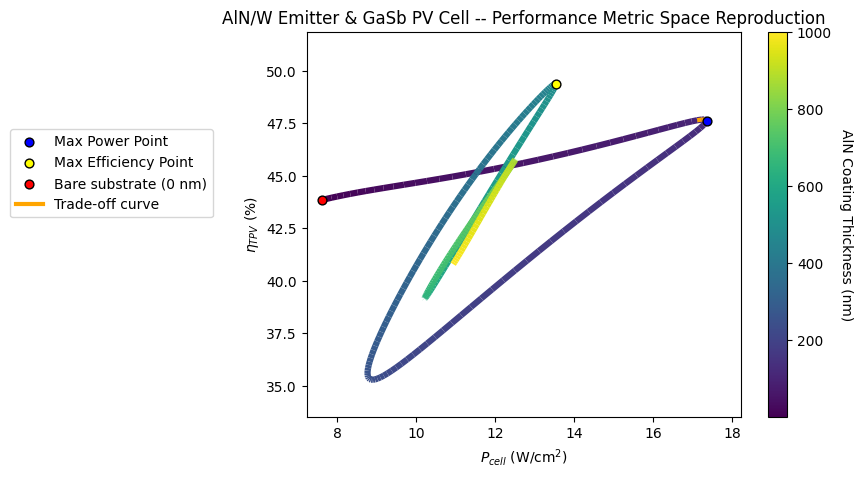

In [8]:
# Section 4, Maximum Power point in Performance Metric Space, Maximum Efficiency Point in Performance Metric Space, and then Trade-off Curves 
idx_MPP = np.argmax(cell_powers) #index of the maximum Power 

P_cell_max = np.max(cell_powers) #maximum power, will be used to plot the maximum power point 
efficiency_MP = efficiency[idx_MPP] #This is the efficiency when the maximum power is reached 

idx_MEP = np.argmax(efficiency) #this is the index of the maximum efficiency \

efficiency_max = np.max(efficiency) 
P_cell_ME = cell_powers[idx_MEP]#Power of the cell (W/cm^2) at maximum efficiency. I would likely plot these as scatter points. 

efficiency_substrate = efficiency[0] #the substrate means the coating thickness is zero, so it should be the very first point in performance metric space. 
P_cell_subsrate = cell_powers[0] 

#the trade-off curve is defined as points in parameter space (defined as (P_cell, efficiency), parametrized by d_coating values) 
#where the P_cell is greater than P_cell_ME, but less than P_cell_max, AND where efficiency is less than efficiency_max but greater than efficiency_MP 
#remember that the entries in efficiency and p_cell go together, so you can't check element 0 in efficiency and element 30 in P_cell, so a for loop might not make sense here. 




from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Build line segments: each segment connects consecutive (P_cell, efficiency) points
points = np.array([cell_powers, efficiency]).T.reshape(-1, 1, 2) #grouping together (P_cell, efficiency) points
                                                                 #.T --> transpose is necessary because it turns it from two rows to two columns, each row is a coordinate pair 
                                                                 # The .reshape(-1,1,2) will reshape the array into (a, b, c) dimensions, where a in this context is determined by -1
                                                                 # The -1 tells .reshape 'how many points do we have?' and then it individually boxes them, so that they can be connected
                                                                 # to form segments between two points. (1,2) just mean (1 row, 2 entries) 
                                                    

segments = np.concatenate([points[:-1], points[1:]], axis=1) # [points[:-1], points[1:]] --> every point BUT the first and last one will be strung together. 
                                                             # axis --> dimensionality, = 1 for a line/curve, 2 would be for a plane, 3 for a solid I'm guessing

# Normalize d_coating values to map onto the colormap
norm = Normalize(vmin=d_coating.min(), vmax=d_coating.max())  #colormaps work by assigning a value between two extremes (0 and 1). The data range we based the color map off, then, has to be normalized
                                                              # So we normalize the d_coating array with the min and max of it. It will assign .min --> 0 and .max --> 1 and linearly scale everything inbetween


lc = LineCollection(segments, cmap='viridis', norm=norm) #We assemble the line collection using the strung up segments, assign the colormap 'viridis', and then use that normalization

lc.set_array(d_coating)  # we assign the linecollection that we've built to the d_coating array. 
                         # .set_array() basically tells the line collection, for segment[i], color it according to d_coating[i]. segments technically has 1 less element
                         # than d_coating because it doesn't involve the endpoints, but python naturally handles it 

lc.set_linewidth(4.5) #changes how thick the line is. 

fig, ax = plt.subplots(figsize=(7,5)) #fig,ax --> creates a figure and axes, .subplots(7,5) --> one plot that is 7 by 5 inches. 
                                      #fig is the blank canvas and ax are the axes labels and curves that actually get drawn. 

line = ax.add_collection(lc) #and this is the step that actually draws/plots the curve. add_collection is storing the curve that we've made to the ax, and ax
                             #is what does the drawing onto the canvas 

#####################################################
mask = ((cell_powers > P_cell_ME) & (cell_powers < P_cell_max) &
        (efficiency > efficiency_MP) & (efficiency < efficiency_max)) #this creates a mask by basically checking all four criteria and then 
                                                                      #creating a 1D array of booleans (true-false). True if all four are met, false otherwise 

# A segment (points[i] -> points[i+1]) only counts as "trade-off" if BOTH
# endpoints satisfy the criteria — this preserves adjacency from the original curve
seg_mask = mask[:-1] & mask[1:] #this creates the mask that we apply to the segments
                                #remember that segments contains the segment between two points, so the mask is being applied to both endpoints of the segment, and if they're met, 
                                #that segment is then classified as being apart of the trade off curve. 

toc_segments = segments[seg_mask]  # reuses the same `segments` array built for the main curve

toc_lc = LineCollection(toc_segments, color='orange', linewidth=3, zorder=2) # zorder determines the order that things are drawn, lower z_order means that it gets drawn first 
                                                                             # higher zorder means that it gets drawn last 
ax.add_collection(toc_lc) #storing the trade-off curve to the collection, and storing it to ax so that it gets plotted 


#####################################################



# Special points
ax.scatter(P_cell_max, efficiency_MP, color='blue', s=40, zorder=3, 
           label='Max Power Point', edgecolor='black')
ax.scatter(P_cell_ME, efficiency_max, color='yellow', s=40, zorder=3, 
           label='Max Efficiency Point', edgecolor='black')
ax.scatter(P_cell_subsrate, efficiency_substrate, color='red', s=40, zorder=3, 
           label='Bare substrate (0 nm)', edgecolor='black')

# Colorbar to show the thickness scale
cbar = fig.colorbar(line, ax=ax) #for the colorbar, the 'line' that we used earlier to make the colorbar becomes the reference , and we're using the same axes 
cbar.set_label('AlN Coating Thickness (nm)', rotation = 270, labelpad = 15) #setting colorbar label 

    #ax. doesn't scale things automatically so we need to scale them manually. Claude chose 0.95 and 1.05 I guess so that we have some room on the extrema on the axes
ax.set_xlim(cell_powers.min()*0.95, cell_powers.max()*1.05)
ax.set_ylim(efficiency.min()*0.95, efficiency.max()*1.05)
ax.set_xlabel(r'$P_{cell}$ (W/cm$^2$)')
ax.set_ylabel(r'$\eta_{TPV}$ (%)')


# --- Legend section: this is where the snippet goes ---
from matplotlib.lines import Line2D

    #creating a proxy for the trade-off curves, proxy = 'substitute', [0], [0] is a throwaway point 
    #linecollection does not automatically get handled by .legend() easily. legend only handles .plot and .scatter, not line collection, nicely 

toc_proxy = Line2D([0], [0], color='orange', linewidth=3, label='Trade-off curve') #trade off curve(s) proxy, Line2D creates a 2d line with the throwaway point
                                                                                    #THIS DOES NOT ACTUALLY GET PLOTTED IT'S PURELY FOR EXISTING IN THE LEGEND!



handles, labels = ax.get_legend_handles_labels()  # handles = objects that get labeled, and so far, we've only labeled the 3 points, 
                                                  # labels = the labels of those objects
                                                  #.get_legend_handles_labels does the work of identifying the objects(handles) and labels() 
handles.append(toc_proxy) #so now we're making the toc_proxy an object 

ax.legend(handles=handles, bbox_to_anchor = (-0.20, 0.5), loc = 'lower right') #handles got updated so we have to make sure that's reflected

# --- end legend section ---

ax.set_title('AlN/W Emitter & GaSb PV Cell -- Performance Metric Space Reproduction')
plt.show()


#my intention here is to have it check both arrays at the same time and see if both conditions are met. if they are, store them 


In [141]:
## Trial Emissivity Calculation at d_coating = 473 nm + Checks 

d_sub = 1E5 #tungsten substrate thickness, 0.1 mm --> 10^5 nanometers 
d_coating = 473 #thickness of AlN coating, varying from 1 nm ---> 1000 nm 

#my TMM functions and other self-written things
theta_incident = (np.pi / 180) * 0 # You can either put in your incident angle directly as radians or put it in as degrees and then convert it to radians. 
                                   # I'll assume normal incidence since nothing was specified --07/09/2026

n_air = 1 #index of refraction of air 

def optical_thickness(lam, k): #unitless quantity 
    return (4 * np.pi * d_sub) * k / lam #where k and lam are the complex part of the refractive index and the wavelength


#performance_metric_space = [] #the list will be populated with (P_cell, efficiency) pairs which correspond to a point in the metric space for a given thickness


emissivity_ALL = []#emissivity across all wavelengths at each thickness (1 nm ---> 1000 nm) 


emissivity_at_this_thickness = []

for i, wl in enumerate(wl_array):

    n_AlN_complex = n_AlN[i] + 1j*k_AlN[i]
    n_W_complex = n_W[i] + 1j*k_W[i] 
    n_array = np.array([n_air, n_AlN_complex, n_W_complex])
    
    if optical_thickness(wl, k_W[i]) > 12: 
        d_array = [inf, d_coating, inf] #if it's opaque, then air/AlN/W --> inf/finite/inf
        R_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[0] #Reflectivity(Reflected Light Intensity) of Structure for Unpolarized Light
        T_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[1]
        A = 1 - R_avg
    else:
        d_array = [inf, d_coating, d_sub] #if it's transparent then air/AlN/w --> inf/finite/finite
        R_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[0]
        T_avg = unpolarized_RT(n_array, d_array, theta_incident, wl)[1]
        A = 1 - R_avg - T_avg #by kirchoff's law, we will assume that the Absorptivity = Emissivity 

    emissivity_at_this_thickness.append(A) #appends the emissivity at that specific wavelength to the list

emissivity_ALL.append(emissivity_at_this_thickness)


#plt.plot(wl_array, emissivity_ALL[0])
#plt.xlabel('wavelength (nm)')
#plt.ylabel('emissivity')
#plt.show()

pchip_emissivity = PchipInterpolator(wl_array, emissivity_ALL[0])

emissivity_interpolated = pchip_emissivity(lam_fine) 

#plt.plot(lam_fine, emissivity_interpolated) 
#plt.xlabel('Wavelength (nm)') 
#plt.ylabel('Emissivity')
#plt.title('interpolation check') 
#plt.show()

BB_spectrum_comparison = BB_spectrum(lam_fine_meters, T_emitter) * 1E-4 * 1E-9 #converting the units from W/m^3 to W / cm^2 / nm 
integrand_fine = BB_spectrum_comparison * emissivity_interpolated

#plt.plot(lam_fine, BB_spectrum_comparison, color = 'blue', label = 'BB spectrum at 1800C') 
#plt.plot(lam_fine, integrand_fine, color = 'orange', label = 'integrand')
#plt.xlabel('Wavelength (nm)') 
#plt.ylabel('(W / cm^2 / nm)') 
#plt.title('Checking BB Spectrum @ 1800C and Integrand')
#plt.show()


P_emit = simpson(integrand_fine, x=lam_fine) #should be in units of W/cm^2 
print(f'{P_emit} W/cm^2') 


#Writing a step-function for the EQE. 0 if we're above bandgap wavelength and 1 if we're at or below it. 

Eg_GaSb = 0.73 #0.73 eV for GaSb

lam_Eg = h_eV * c / Eg_GaSb # should come out to be in units of meters for the wavelength

lam_GaSb = lam_Eg * 1E9 #converting it to nm 

def EQE(lam): #assumes that lam is in nanometers 
    return np.where(lam < lam_GaSb, 1, 0) #first entry in the argument is the condition, second is the result if it's met, and third is the result when it's not met





#Checking to see what's wrong with my P_cell 
def n_B(lam, T): #temperature should be input in Kelvin and lam should be input in meters 
    numerator = (2 * c) #m/s 
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #in units of m^4
    return numerator/denominator   #has units of s^-1 * m^3 if you input lam in [m] 

    

n_B_array_LIGHT = n_B(lam_fine_meters, T_emitter) #Blackbody Spectral Photon Radiance, as defined in Declan's slides on 08/02/23. Might have to check back if there's something wrong 
n_B_array_DARK = n_B(lam_fine_meters, T_c)                                    

integrand_JL = q * np.pi * emissivity_interpolated * n_B_array_LIGHT * EQE_array  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                #integrating it will give A/m^2 which is appropriate for current density. 

integrand_J0 = q * np.pi * n_B_array_DARK * EQE_array

J_L = simpson(integrand_JL, x=lam_fine_meters) #light-induced current density given in A/m^2 

J_0 = simpson(integrand_J0, x=lam_fine_meters) #dark-current density given in A/m^2 

V_oc = (np.log((J_L / J_0) + 1)) * kb_eV * T_c #in units of Volts, the open circuit voltage (I = 0)

V_vals = np.linspace(0, V_oc, 200) #creates the array of possible voltage values for IV curve

P_derivs = P_derivative(J_L, J_0, V_vals) #calculates the derivatives of Power wrt Voltage 

differences = np.abs(P_derivs - P_deriv_target) #apart of finding where the voltage that produces P_max is  

idx = np.argmin(differences) 

V_pmax = V_vals[idx] #voltage that produes P_max 

J_pmax = J(J_L, J_0, V_pmax) #Current-density in A/m^2 that produces P_max 

P_max = J_pmax * V_pmax # Maximum Cell Power in units of W/m^2 

print(P_max * 1E-4 / np.pi)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")




8.720877355627163 W/cm^2
4.307904921078729
Runtime: 220.507850 seconds
